## Level 4 – Weather-Driven Highway Accidents

## Problem Statement

Supervised regression problem. We aim to predict the daily number of road accidents on highways using meteorological data. The objective is to help Grupo Brisa manage emergency vehicle allocation, in which 3 vehicles are needed per accident.

**Why a Supervised Learning Problem?**
- Labeled target values (daily accident counts per location)
- We want to measure prediction accuracy with a specific error metric
- Training on historical weather, relationships to predict future accidents

**Prediction Task:** Given daily weather features (temperature, humidity, rainfall, wind, pressure, etc.) for a location and date, predict the number of accidents that will occur.

**Evaluation Metric (Vehicle Error):**
Vehicle Error = |3 x actual_accidents − predicted_vehicles|

Predicted_vehicles is our model's predicted accident count x 3. This metric penalizes both overestimation (too many vehicles sent) and underestimation (insufficient response). **This is an important security topic, we should always favor overestimation over underestimation.**

**Data Overview:**
- **Accidents Dataset**: Daily accident counts per location (18 districts, from 2025-12-29 to 2026-03-05)
- **Meteorology Dataset**: Hourly weather measurements per location (starting 2025-03-05, multiple features including temperature, humidity, rain, wind, pressure)
- **Objective**: Align hourly weather data to daily granularity and match time periods.

**Approach:**
1. Load and explore datasets
2. Align temporal ranges and aggregate hourly weather to daily
3. Exploratory analysis (EDA) with visualizations (correlations, distributions, outliers)
4. Feature engineering based on graphical evidence
5. Train-validation-test split (70-15-15, chronological order)
6. Train linear regression as baseline
7. Evaluate with Vehicle Error metric
8. Plan for addittions (snow feature, more complex/self-made models)

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import warnings
warnings.filterwarnings('ignore')

# Plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Paths
base_path = Path('..').resolve()
accidents_path = base_path / 'accidents_dataset.csv'
meteorology_path = base_path / 'metherology_dataset.csv'

print(f"Base path: {base_path}")
print(f"Accidents file exists: {accidents_path.exists()}")
print(f"Meteorology file exists: {meteorology_path.exists()}")

Base path: /home/nhanho/Desktop/EBEC - Hackathon/Weather-Prediction
Accidents file exists: True
Meteorology file exists: True


In [7]:
# Load datasets
accidents_df = pd.read_csv(accidents_path)
meteorology_df = pd.read_csv(meteorology_path)

print("="*80)
print("ACCIDENTS DATASET")
print("="*80)
print(f"Shape: {accidents_df.shape}")
print(f"\nColumn names and types:")
print(accidents_df.dtypes)
print(f"\nFirst few rows:")
print(accidents_df.head(10))
print(f"\nBasic statistics:")
print(accidents_df.describe())

ACCIDENTS DATASET
Shape: (1206, 3)

Column names and types:
location       str
accidents    int64
time           str
dtype: object

First few rows:
         location  accidents        time
0          Aveiro         36  2025-12-29
1            Beja          7  2025-12-29
2           Braga         22  2025-12-29
3        Bragança          7  2025-12-29
4  Castelo Branco         11  2025-12-29
5         Coimbra         12  2025-12-29
6           Évora         10  2025-12-29
7            Faro         28  2025-12-29
8          Guarda          9  2025-12-29
9          Leiria         13  2025-12-29

Basic statistics:
         accidents
count  1206.000000
mean     23.539801
std      24.303537
min       0.000000
25%       6.000000
50%      15.000000
75%      31.000000
max     144.000000


In [8]:
print("\n" + "="*80)
print("METEOROLOGY DATASET")
print("="*80)
print(f"Shape: {meteorology_df.shape}")
print(f"\nColumn names and types:")
print(meteorology_df.dtypes)
print(f"\nFirst few rows:")
print(meteorology_df.head(10))
print(f"\nBasic statistics (sample of numeric columns):")
print(meteorology_df.describe())


METEOROLOGY DATASET
Shape: (158112, 17)

Column names and types:
location                    str
time                        str
temperature_2m          float64
relative_humidity_2m      int64
dew_point_2m            float64
rain                    float64
cloud_cover               int64
cloud_cover_low           int64
cloud_cover_mid           int64
cloud_cover_highh         int64
wind_speed_10m          float64
wind_direction_10m        int64
wind_gusts_10m          float64
wind_direction_100m       int64
wind_speed_100m         float64
pressure_msl            float64
surface_pressure        float64
dtype: object

First few rows:
  location              time  temperature_2m   relative_humidity_2m  \
0   Aveiro  2025-03-05T00:00             11.6                    79   
1   Aveiro  2025-03-05T01:00             11.2                    90   
2   Aveiro  2025-03-05T02:00             11.1                    90   
3   Aveiro  2025-03-05T03:00             10.4                    94   
4   

In [9]:
# Check temporal ranges and data alignment
print("\n" + "="*80)
print("DATA ALIGNMENT & TEMPORAL RANGES")
print("="*80)

# Accidents data
accidents_df['time'] = pd.to_datetime(accidents_df['time'])
print(f"\nAccidents data date range: {accidents_df['time'].min()} to {accidents_df['time'].max()}")
print(f"Locations in accidents data: {accidents_df['location'].nunique()}")
print(f"Unique locations: {sorted(accidents_df['location'].unique())}")

# Meteorology data
meteorology_df['time'] = pd.to_datetime(meteorology_df['time'])
print(f"\nMeteorology data date range: {meteorology_df['time'].min()} to {meteorology_df['time'].max()}")
print(f"Locations in meteorology data: {meteorology_df['location'].nunique()}")

# Data alignment issue
print(f"\nTemporal Range Issue:")
print(f"  - Meteorology starts: {meteorology_df['time'].min()}")
print(f"  - Accidents starts: {accidents_df['time'].min()}")
print(f"  - Meteorology data BEFORE accidents: {(meteorology_df['time'].min() < accidents_df['time'].min())}")
print(f"  - Days to trim from meteorology: {(accidents_df['time'].min() - meteorology_df['time'].min()).days} days")
print(f"\nAction: We will trim meteorology data to start from {accidents_df['time'].min()}")


DATA ALIGNMENT & TEMPORAL RANGES

Accidents data date range: 2025-12-29 00:00:00 to 2026-03-05 00:00:00
Locations in accidents data: 18
Unique locations: ['Aveiro', 'Beja', 'Braga', 'Bragança', 'Castelo Branco', 'Coimbra', 'Faro', 'Guarda', 'Leiria', 'Lisboa', 'Portalegre', 'Porto', 'Santarém', 'Setúbal', 'Viana do Castelo', 'Vila Real', 'Viseu', 'Évora']

Meteorology data date range: 2025-03-05 00:00:00 to 2026-03-05 23:00:00
Locations in meteorology data: 18

Temporal Range Issue:
  - Meteorology starts: 2025-03-05 00:00:00
  - Accidents starts: 2025-12-29 00:00:00
  - Meteorology data BEFORE accidents: True
  - Days to trim from meteorology: 299 days

Action: We will trim meteorology data to start from 2025-12-29 00:00:00


## Phase 2: Data Preparation & Alignment

### Step 1: Trim and Aggregate Meteorology Data

As the meteorology dataset starts in March 2025, but accident data only begins on 2025-12-29. We need to:
1. Remove all meteorology data before the first accident date
2. Aggregate hourly weather measurements to daily statistics (mean, max, min when appropriate)
3. Align both datasets by location and date for merging

This aggregation is justified by the task: we want to predict daily accidents from daily weather patterns. The loss of information is justified by the proportional gains in predictive power.

In [10]:
# Trim meteorology data to match accidents time interaval
cutoff_date = accidents_df['time'].min()

meteorology_df_trimmed = meteorology_df[meteorology_df['time'] >= cutoff_date].copy()

print("METEOROLOGY DATA TRIMMING")
print("="*80)
print(f"Original meteorology shape: {meteorology_df.shape}")
print(f"Trimmed meteorology shape: {meteorology_df_trimmed.shape}")
print(f"Date range after trim: {meteorology_df_trimmed['time'].min()} to {meteorology_df_trimmed['time'].max()}")
print(f"Records removed: {meteorology_df.shape[0] - meteorology_df_trimmed.shape[0]}")


METEOROLOGY DATA TRIMMING
Original meteorology shape: (158112, 17)
Trimmed meteorology shape: (28944, 17)
Date range after trim: 2025-12-29 00:00:00 to 2026-03-05 23:00:00
Records removed: 129168


In [11]:
# Step 2: Aggregate hourly to daily meteorology data
# Clean column names (strip whitespace) so aggregation keys match
meteorology_df_trimmed.columns = meteorology_df_trimmed.columns.str.strip()

# Extract date (without time) for grouping
meteorology_df_trimmed['date'] = meteorology_df_trimmed['time'].dt.date

# Aggregation strategy: 
# - Temperature, humidity, dew point, pressure: daily MEAN (representative of daily conditions)
# - Rain: daily SUM (total precipitation for the day)
# - Cloud cover: daily MEAN
# - Wind: daily MEAN (average wind speed)

aggregation_ops = {
    'temperature_2m': 'mean',
    'relative_humidity_2m': 'mean',
    'dew_point_2m': 'mean',
    'rain': 'sum',
    'cloud_cover': 'mean',
    'cloud_cover_low': 'mean',
    'cloud_cover_mid': 'mean',
    'cloud_cover_highh': 'mean',
    'wind_speed_10m': 'mean',
    'wind_direction_10m': 'mean',
    'wind_gusts_10m': 'mean',
    'wind_direction_100m': 'mean',
    'wind_speed_100m': 'mean',
    'pressure_msl': 'mean',
    'surface_pressure': 'mean'
}

meteorology_daily = meteorology_df_trimmed.groupby(['location', 'date']).agg(aggregation_ops).reset_index()

# Convert date back to datetime for consistency
meteorology_daily['date'] = pd.to_datetime(meteorology_daily['date'])

print("METEOROLOGY DAILY AGGREGATION")
print("="*80)
print(f"Daily meteorology shape: {meteorology_daily.shape}")
print(f"Locations: {meteorology_daily['location'].nunique()}")
print(f"Date range: {meteorology_daily['date'].min()} to {meteorology_daily['date'].max()}")
print(f"Days of data: {meteorology_daily['date'].nunique()}")
print(f"\nFirst 5 rows of daily meteorology:")
print(meteorology_daily.head())


METEOROLOGY DAILY AGGREGATION
Daily meteorology shape: (1206, 17)
Locations: 18
Date range: 2025-12-29 00:00:00 to 2026-03-05 00:00:00
Days of data: 67

First 5 rows of daily meteorology:
  location       date  temperature_2m  relative_humidity_2m  dew_point_2m  \
0   Aveiro 2025-12-29        8.045833             89.833333      6.237500   
1   Aveiro 2025-12-30        7.537500             92.083333      6.191667   
2   Aveiro 2025-12-31        7.641667             87.833333      5.575000   
3   Aveiro 2026-01-01       10.362500             77.708333      6.608333   
4   Aveiro 2026-01-02       14.141667             72.666667      9.283333   

   rain  cloud_cover  cloud_cover_low  cloud_cover_mid  cloud_cover_highh  \
0   0.0    51.833333        51.833333         0.250000           0.000000   
1   0.0    55.166667        53.541667         2.125000           0.000000   
2   0.0    80.875000        37.750000        20.166667          45.666667   
3   4.2   100.000000        17.416667    

In [12]:
# Step 3: Prepare accidents dataset and merge with meteorology data
# Extract date from accidents dataset
accidents_df['date'] = accidents_df['time'].dt.date
accidents_df['date'] = pd.to_datetime(accidents_df['date'])

# Rename 'accidents' to 'accident_count' for clarity
accidents_df.rename(columns={'accidents': 'accident_count'}, inplace=True)

# Merge on location and date
merged_df = pd.merge(
    accidents_df[['location', 'date', 'accident_count']],
    meteorology_daily,
    on=['location', 'date'],
    how='inner'  # Use inner join to keep only matching dates
)

print("DATASET MERGING")
print("="*80)
print(f"Accidents shape (before merge): {accidents_df[['location', 'date', 'accident_count']].shape}")
print(f"Meteorology daily shape: {meteorology_daily.shape}")
print(f"Merged dataset shape: {merged_df.shape}")
print(f"Locations in merged data: {merged_df['location'].nunique()}")
print(f"Date range in merged data: {merged_df['date'].min()} to {merged_df['date'].max()}")
print(f"Days of data in merged: {merged_df['date'].nunique()}")
print(f"\nFirst 5 rows of merged dataset:")
print(merged_df.head())
print(f"\nMerged dataset info:")
print(merged_df.info())


DATASET MERGING
Accidents shape (before merge): (1206, 3)
Meteorology daily shape: (1206, 17)
Merged dataset shape: (1206, 18)
Locations in merged data: 18
Date range in merged data: 2025-12-29 00:00:00 to 2026-03-05 00:00:00
Days of data in merged: 67

First 5 rows of merged dataset:
         location       date  accident_count  temperature_2m  \
0          Aveiro 2025-12-29              36        8.045833   
1            Beja 2025-12-29               7        8.237500   
2           Braga 2025-12-29              22        7.979167   
3        Bragança 2025-12-29               7        4.616667   
4  Castelo Branco 2025-12-29              11        7.554167   

   relative_humidity_2m  dew_point_2m  rain  cloud_cover  cloud_cover_low  \
0             89.833333      6.237500   0.0    51.833333        51.833333   
1             89.541667      6.462500   0.0    33.375000        31.791667   
2             80.416667      4.587500   0.0     2.208333         1.416667   
3             81.7083

In [13]:
# Step 4: Analyze missing values
print("\nMISSING VALUES ANALYSIS")
print("="*80)

missing_counts = merged_df.isnull().sum()
missing_pct = (missing_counts / len(merged_df)) * 100

missing_summary = pd.DataFrame({
    'Column': missing_counts.index,
    'Missing Count': missing_counts.values,
    'Missing %': missing_pct.values
})

missing_summary = missing_summary[missing_summary['Missing Count'] > 0].sort_values('Missing %', ascending=False)

if len(missing_summary) > 0:
    print("Columns with missing values:")
    print(missing_summary.to_string(index=False))
else:
    print("No missing values detected in merged dataset. Data quality is good! 🤑🥳")

print(f"\nDataset dimensions: {merged_df.shape[0]} rows, {merged_df.shape[1]} columns")
print(f"Usable feature columns: {merged_df.shape[1] - 2} (excluding 'location' and 'date')")



MISSING VALUES ANALYSIS
No missing values detected in merged dataset. Data quality is good! 🤑🥳

Dataset dimensions: 1206 rows, 18 columns
Usable feature columns: 16 (excluding 'location' and 'date')


## Phase 3: Exploratory Data Analysis

### Understanding the Data Distribution

In this phase, we visualize the accident counts, weather features, and their relationships. This graphical evidence will guide our feature engineering decisions later. Each visualization answers a specific question:

1. **Accident Distribution**: How many accidents occur daily? Are there outliers?
2. **Weather Patterns**: What is the range and variation of weather features?
3. **Correlation Analysis**: Which weather features show visible relationships with accidents?
4. **Temporal Patterns**: Do accidents vary by date or location consistently?

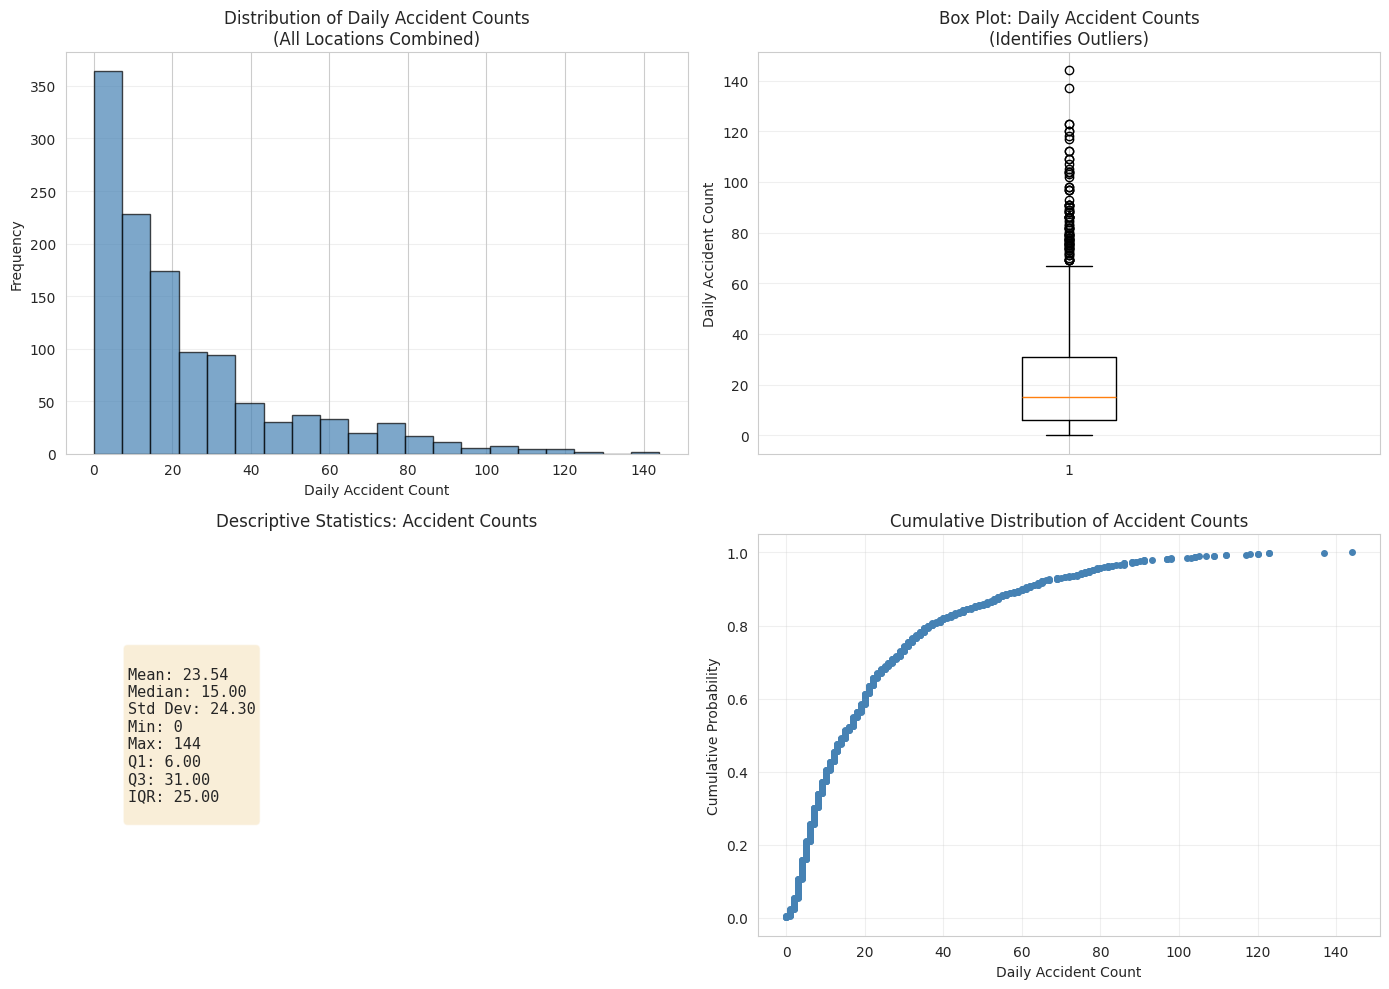

ACCIDENT COUNT STATISTICS
count    1206.000000
mean       23.539801
std        24.303537
min         0.000000
25%         6.000000
50%        15.000000
75%        31.000000
max       144.000000
Name: accident_count, dtype: float64


In [14]:
# Visualization 1: Accident Count Distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram of accident counts
axes[0, 0].hist(merged_df['accident_count'], bins=20, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Daily Accident Count')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Daily Accident Counts\n(All Locations Combined)')
axes[0, 0].grid(axis='y', alpha=0.3)

# Box plot to identify outliers
axes[0, 1].boxplot(merged_df['accident_count'], vert=True)
axes[0, 1].set_ylabel('Daily Accident Count')
axes[0, 1].set_title('Box Plot: Daily Accident Counts\n(Identifies Outliers)')
axes[0, 1].grid(axis='y', alpha=0.3)

# Descriptive statistics
stats_text = f"""
Mean: {merged_df['accident_count'].mean():.2f}
Median: {merged_df['accident_count'].median():.2f}
Std Dev: {merged_df['accident_count'].std():.2f}
Min: {merged_df['accident_count'].min():.0f}
Max: {merged_df['accident_count'].max():.0f}
Q1: {merged_df['accident_count'].quantile(0.25):.2f}
Q3: {merged_df['accident_count'].quantile(0.75):.2f}
IQR: {merged_df['accident_count'].quantile(0.75) - merged_df['accident_count'].quantile(0.25):.2f}
"""
axes[1, 0].text(0.1, 0.5, stats_text, fontsize=11, verticalalignment='center', 
                family='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
axes[1, 0].axis('off')
axes[1, 0].set_title('Descriptive Statistics: Accident Counts')

# Cumulative distribution
sorted_accidents = np.sort(merged_df['accident_count'])
cumulative = np.arange(1, len(sorted_accidents) + 1) / len(sorted_accidents)
axes[1, 1].plot(sorted_accidents, cumulative, marker='.', linestyle='none', markersize=8, color='steelblue')
axes[1, 1].set_xlabel('Daily Accident Count')
axes[1, 1].set_ylabel('Cumulative Probability')
axes[1, 1].set_title('Cumulative Distribution of Accident Counts')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("ACCIDENT COUNT STATISTICS")
print("="*80)
print(merged_df['accident_count'].describe())


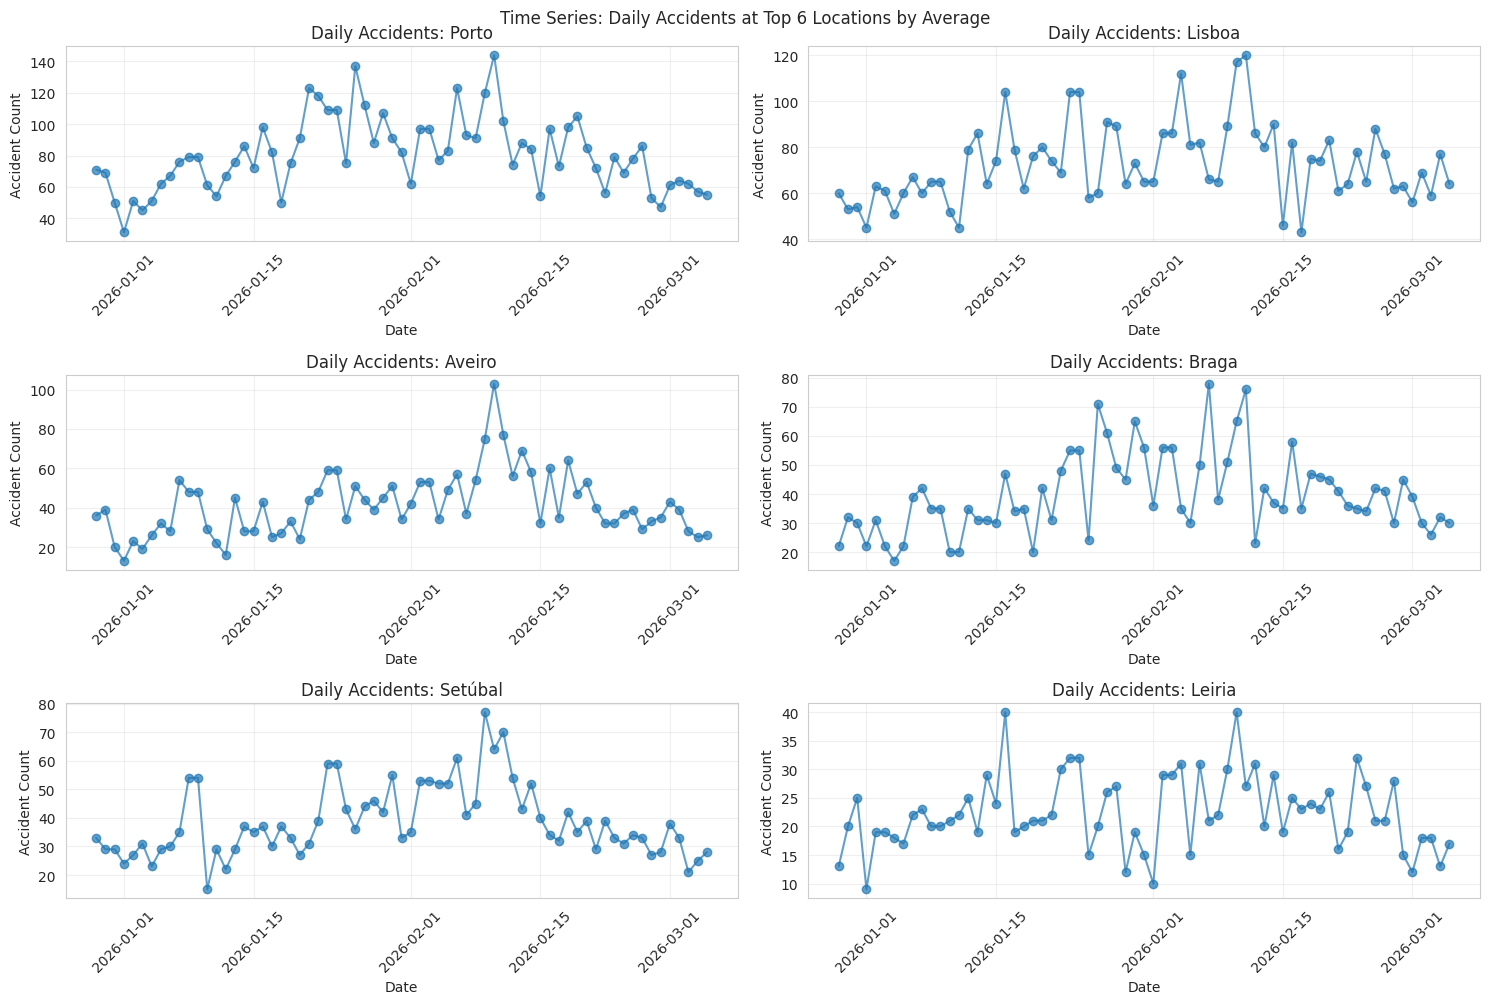

TOP 6 LOCATIONS BY AVERAGE DAILY ACCIDENTS
               mean        std  min  max  count
location                                       
Porto     80.298507  23.309521   31  144     67
Lisboa    72.641791  16.948855   43  120     67
Aveiro    41.194030  15.971792   13  103     67
Braga     39.611940  13.846513   17   78     67
Setúbal   38.641791  12.428830   15   77     67
Leiria    22.358209   6.496389    9   40     67


In [15]:
# Visualization 2: Time Series of Accidents by Location
# Select a subset of locations for clarity (top 6 by mean accidents)
top_locations = merged_df.groupby('location')['accident_count'].mean().nlargest(6).index.tolist()

fig, axes = plt.subplots(3, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, location in enumerate(top_locations):
    location_data = merged_df[merged_df['location'] == location].sort_values('date')
    axes[idx].plot(location_data['date'], location_data['accident_count'], marker='o', linestyle='-', label=location, alpha=0.7)
    axes[idx].set_title(f'Daily Accidents: {location}')
    axes[idx].set_xlabel('Date')
    axes[idx].set_ylabel('Accident Count')
    axes[idx].grid(alpha=0.3)
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.suptitle('Time Series: Daily Accidents at Top 6 Locations by Average', y=1.00, fontsize=12)
plt.show()

print("TOP 6 LOCATIONS BY AVERAGE DAILY ACCIDENTS")
print("="*80)
location_stats = merged_df.groupby('location')['accident_count'].agg(['mean', 'std', 'min', 'max', 'count'])
print(location_stats.sort_values('mean', ascending=False).head(6))


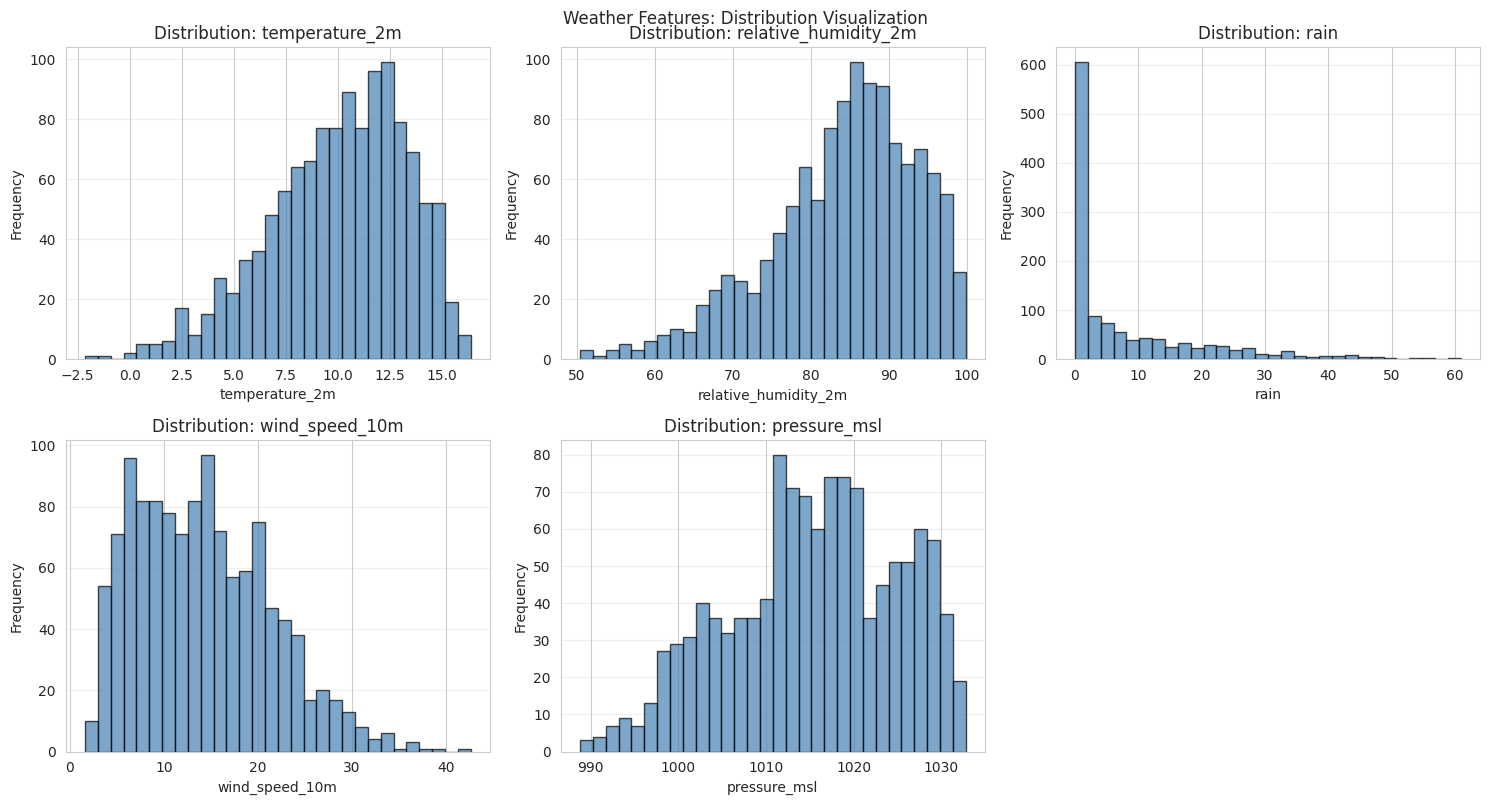

WEATHER FEATURES STATISTICS
       temperature_2m  relative_humidity_2m         rain  wind_speed_10m  \
count     1206.000000           1206.000000  1206.000000     1206.000000   
mean        10.068107             84.189849     8.019403       14.143619   
std          3.287970              9.422888    11.614916        7.166314   
min         -2.145833             50.375000     0.000000        1.625000   
25%          7.897917             78.750000     0.000000        8.236458   
50%         10.493750             85.645833     2.000000       13.529167   
75%         12.529167             91.281250    12.200000       19.238542   
max         16.404167             99.875000    60.900000       42.604167   

       pressure_msl  
count   1206.000000  
mean    1015.388740  
std        9.665182  
min      988.775000  
25%     1008.973958  
50%     1015.927083  
75%     1023.408333  
max     1032.775000  


In [16]:
# Visualization 3: Weather Feature Distributions
# Select key weather features for inspection
key_features = ['temperature_2m', 'relative_humidity_2m', 'rain', 'wind_speed_10m', 'pressure_msl']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, feature in enumerate(key_features):
    axes[idx].hist(merged_df[feature], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Frequency')
    axes[idx].set_title(f'Distribution: {feature}')
    axes[idx].grid(axis='y', alpha=0.3)

# Hide extra subplot
axes[5].axis('off')

plt.tight_layout()
plt.suptitle('Weather Features: Distribution Visualization', y=1.00, fontsize=12)
plt.show()

print("WEATHER FEATURES STATISTICS")
print("="*80)
print(merged_df[key_features].describe())


CORRELATION WITH ACCIDENT COUNT (Top Features)
surface_pressure       0.422992
temperature_2m         0.310885
dew_point_2m           0.278143
rain                   0.194143
wind_gusts_10m         0.160684
wind_speed_100m        0.159183
wind_speed_10m         0.154468
cloud_cover_mid        0.108195
wind_direction_100m    0.103303
wind_direction_10m     0.096096
Name: accident_count, dtype: float64

BOTTOM FEATURES (Negative Correlation)
cloud_cover_highh       0.063572
cloud_cover             0.028843
cloud_cover_low        -0.024611
relative_humidity_2m   -0.033377
pressure_msl           -0.078025
Name: accident_count, dtype: float64


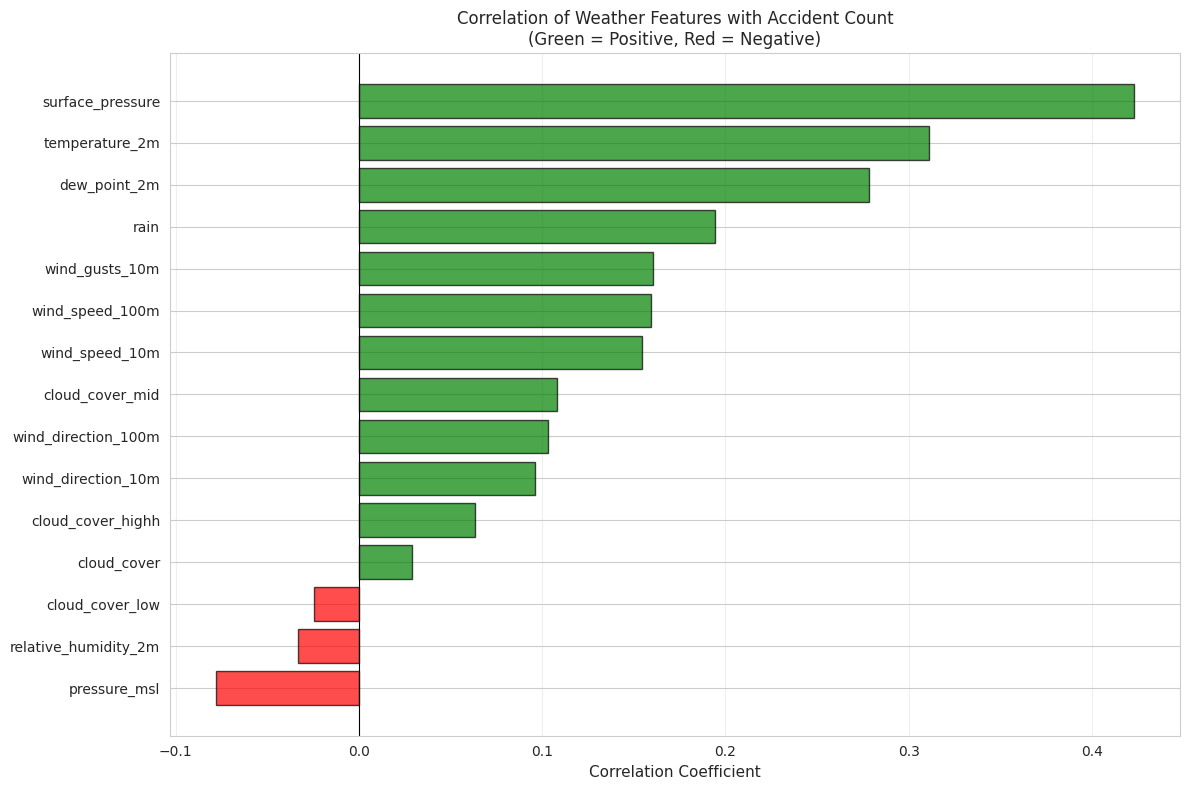

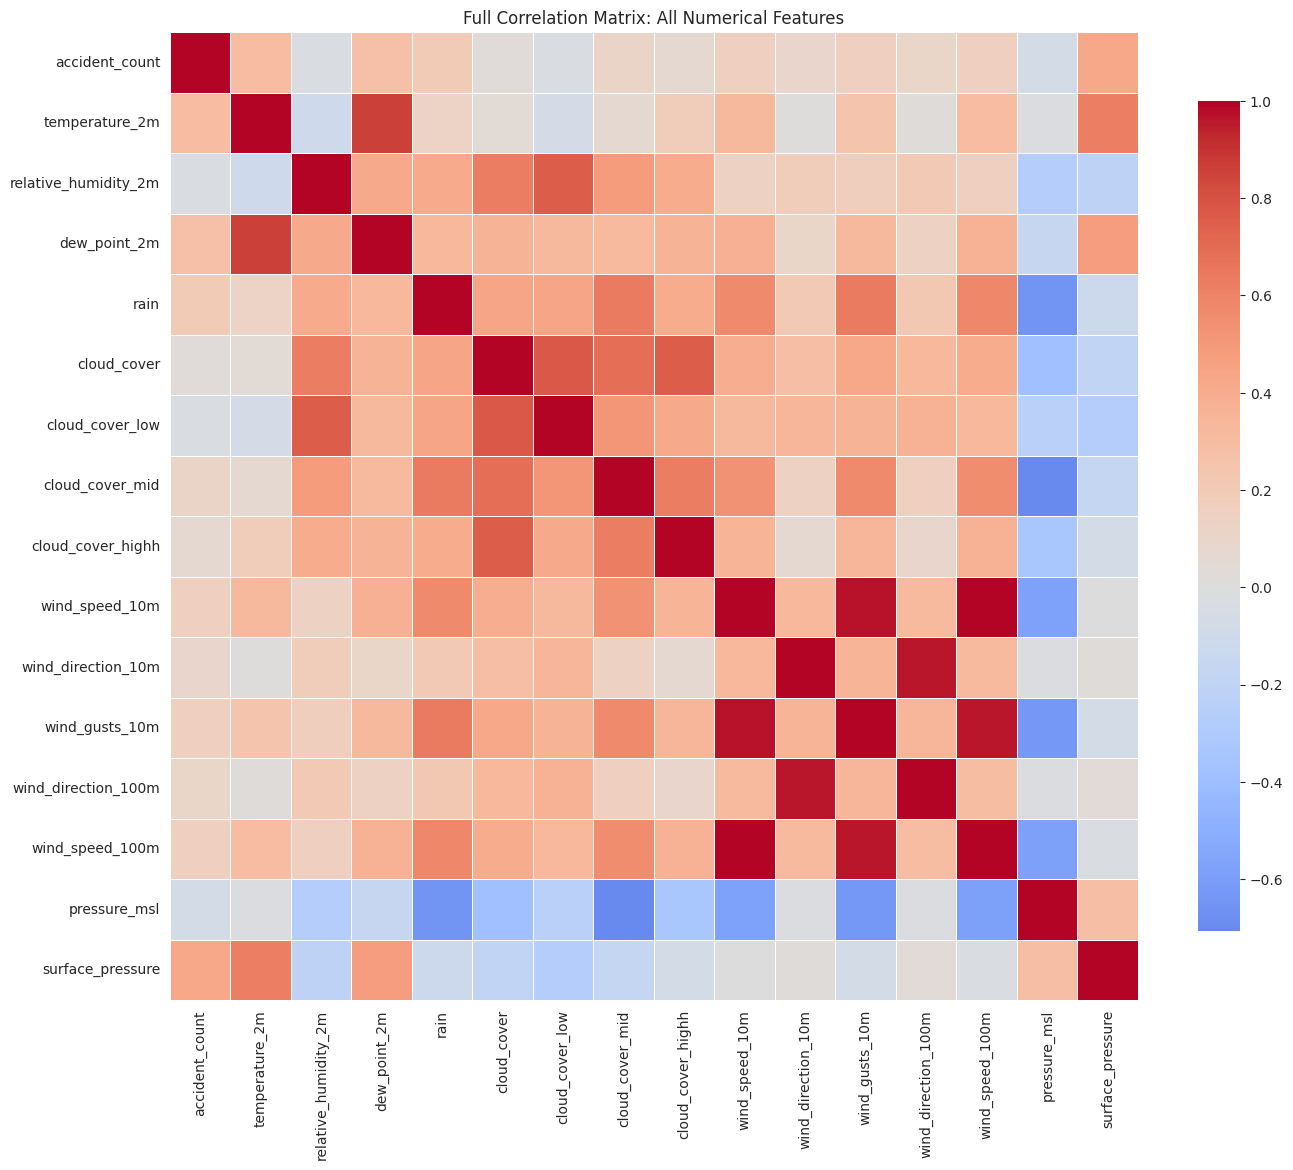


INTERPRETATION:
Positive correlations: Weather features that increase with accident count
Negative correlations: Weather features that decrease with accident count
Stronger correlations (|r| > 0.3) are candidates for feature engineering


In [17]:
# Visualization 4: Correlation Heatmap (Weather Features vs Accidents)
# This is critical for understanding feature-target relationships and will guide feature selection

# Select numerical columns (exclude location and date)
numerical_cols = merged_df.select_dtypes(include=[np.number]).columns.tolist()

# Calculate correlation matrix
correlation_matrix = merged_df[numerical_cols].corr()

# Extract correlations with accident_count
accident_correlations = correlation_matrix['accident_count'].drop('accident_count').sort_values(ascending=False)

print("CORRELATION WITH ACCIDENT COUNT (Top Features)")
print("="*80)
print(accident_correlations.head(10))
print("\nBOTTOM FEATURES (Negative Correlation)")
print(accident_correlations.tail(5))

# Visualize correlation heatmap (focused on accident_count)
fig, ax = plt.subplots(figsize=(12, 8))

# Create a dataframe with correlations sorted
corr_df = pd.DataFrame(accident_correlations).sort_values('accident_count')
colors = ['red' if x < 0 else 'green' for x in corr_df['accident_count']]

ax.barh(range(len(corr_df)), corr_df['accident_count'], color=colors, alpha=0.7, edgecolor='black')
ax.set_yticks(range(len(corr_df)))
ax.set_yticklabels(corr_df.index, fontsize=10)
ax.set_xlabel('Correlation Coefficient', fontsize=11)
ax.set_title('Correlation of Weather Features with Accident Count\n(Green = Positive, Red = Negative)', fontsize=12)
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Full correlation matrix visualization (all numerical features)
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Full Correlation Matrix: All Numerical Features', fontsize=12)
plt.tight_layout()
plt.show()

print("\nINTERPRETATION:")
print("="*80)
print("Positive correlations: Weather features that increase with accident count")
print("Negative correlations: Weather features that decrease with accident count")
print("Stronger correlations (|r| > 0.3) are candidates for feature engineering")
